# LSTM-Autoencoder Training on Google Colab (T4 GPU)
## Cold Chain EWS Digital Twin — Milestone 4a / 4b

---

> **⚠ STRUCTURAL PROXY NOTICE**  
> All data in this notebook derives from `IOT-temp.csv` — a **generic IoT temperature sensor log,  
> NOT real refrigerated-transport telemetry**. All features and models are **synthetic proxy constructs**.  
> No loss value or reconstruction threshold makes any food-safety claim.  
> See `docs/data_profile.md` and `docs/AD_LOG.md` (decisions D1, D9, D10, D11, D12).

---

### Colab Setup Instructions (Automated GitHub Workflow)

1. **Set up GitHub PAT in Colab Secrets**:
   - On the left toolbar in Google Colab, click the **Secrets** icon (the key 🔑).
   - Click **Add new secret**.
   - Name: `GITHUB_TOKEN` (or `GH_TOKEN`).
   - Value: Your GitHub Personal Access Token (classic or fine-grained with `repo` / contents write permissions).
   - Toggle **Notebook access** to **ON**.
2. **GPU Hardware Accelerator**:
   - Ensure a GPU runtime is selected: **Runtime > Change runtime type > Hardware accelerator > T4 GPU**.
3. **Automated Git Workflow**:
   - Running this notebook will automatically clone `https://github.com/Krishna200608/coldchain-ews-twin` using your PAT token.
   - The preprocessed window files (lstm_windows_{out,in}_{train,val}.npz) are automatically loaded directly from data/processed/ in the cloned repository.
   - Training executes on the Colab T4 GPU.
   - Once training completes, the notebook **automatically commits and pushes** the trained model weights (`models/lstm_out.h5`, `models/lstm_in.h5`) and training logs (`data/processed/lstm_training_log_{out,in}.json`) directly back to the GitHub repository's `main` branch!


In [2]:
# 1. Authenticate with GitHub via Colab Secrets & Clone Repository
import os
import sys

# Retrieve GitHub PAT from Colab Secrets
try:
    from google.colab import userdata
    for token_key in ["GITHUB_PAT_TOKEN", "GH_TOKEN", "PAT"]:
        try:
            GITHUB_TOKEN = userdata.get(token_key)
            if GITHUB_TOKEN:
                print(f"Successfully retrieved GitHub token from secret key '{token_key}'.")
                break
        except Exception:
            continue
    else:
        raise ValueError("Could not find secret 'GITHUB_TOKEN' (or 'GH_TOKEN' / 'PAT').")
except Exception as e:
    raise RuntimeError(
        "Please add a secret named 'GITHUB_TOKEN' in Colab's Secrets tab (key icon on left sidebar) "
        "with your GitHub Personal Access Token and enable 'Notebook access'."
    ) from e

REPO_NAME = "coldchain-ews-twin"
REPO_OWNER = "Krishna200608"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/{REPO_OWNER}/{REPO_NAME}.git"

# Clone or pull latest
if not os.path.exists(REPO_NAME):
    print(f"Cloning {REPO_NAME} from GitHub...")
    !git clone {REPO_URL}
else:
    print(f"Repository {REPO_NAME} already exists. Pulling latest commits...")
    %cd {REPO_NAME}
    !git remote set-url origin {REPO_URL}
    !git pull
    %cd ..

# Enter repository root
%cd {REPO_NAME}
print(f"Current working directory: {os.getcwd()}")


Successfully retrieved GitHub token from secret key 'GITHUB_PAT_TOKEN'.
Cloning coldchain-ews-twin from GitHub...
Cloning into 'coldchain-ews-twin'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 115 (delta 46), reused 96 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (115/115), 1.49 MiB | 4.00 MiB/s, done.
Resolving deltas: 100% (46/46), done.
/content/coldchain-ews-twin
Current working directory: /content/coldchain-ews-twin


In [3]:
# 2. Hardware & GPU Environment Verification
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("Physical GPUs Detected:", gpus)

# Enforce that training occurs on a GPU
assert len(gpus) > 0, "No GPU detected! Please navigate to Runtime > Change runtime type > T4 GPU."

# Display GPU hardware specifications via nvidia-smi
!nvidia-smi


TensorFlow Version: 2.20.0
Physical GPUs Detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Thu Sep 17 16:24:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                     

In [4]:
# 3. Data File Verification & Upload (if needed)
import pathlib
import numpy as np

pathlib.Path("models").mkdir(parents=True, exist_ok=True)
pathlib.Path("data/processed").mkdir(parents=True, exist_ok=True)

required_files = [
    "data/processed/lstm_windows_out_train.npz",
    "data/processed/lstm_windows_out_val.npz",
    "data/processed/lstm_windows_in_train.npz",
    "data/processed/lstm_windows_in_val.npz",
]

missing_files = []
for f in required_files:
    p = pathlib.Path(f)
    # Check if file was uploaded to root and needs moving
    if not p.exists() and pathlib.Path(p.name).exists():
        pathlib.Path(p.name).rename(p)
    if not p.exists():
        missing_files.append(f)

if missing_files:
    print(f"The following required window files are missing: {missing_files}")
    print("Please upload the .npz files using the upload button below:")
    from google.colab import files
    uploaded = files.upload()
    for fname in uploaded.keys():
        dest = pathlib.Path("data/processed") / fname
        pathlib.Path(fname).rename(dest)
        print(f"Moved {fname} -> {dest}")

# Verify all required files are present and inspect shapes
for f in required_files:
    p = pathlib.Path(f)
    assert p.exists(), f"Error: {f} is still missing. Please upload it."
    arr = np.load(p)["windows"]
    print(f"Verified {f:42s}: shape={arr.shape}, dtype={arr.dtype}")


Verified data/processed/lstm_windows_out_train.npz : shape=(11494, 30, 2), dtype=float64
Verified data/processed/lstm_windows_out_val.npz   : shape=(1272, 30, 2), dtype=float64
Verified data/processed/lstm_windows_in_train.npz  : shape=(2978, 30, 2), dtype=float64
Verified data/processed/lstm_windows_in_val.npz    : shape=(326, 30, 2), dtype=float64


In [5]:
# 4. Model Architecture Definition (D12)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping
import time
import json

LSTM_WINDOW_LENGTH = 30
N_FEATURES = 2
BATCH_SIZE = 256
MAX_EPOCHS = 50
PATIENCE = 5

def build_lstm_autoencoder(window_length=LSTM_WINDOW_LENGTH, n_features=N_FEATURES):
    """
    Builds the D12 LSTM-Autoencoder architecture:
    Encoder LSTM(32) -> Bottleneck -> RepeatVector(30) -> Decoder LSTM(32, return_sequences=True) -> TimeDistributed(Dense(2))
    Adam optimizer, MSE loss.
    """
    model = Sequential([
        LSTM(32, activation="tanh", input_shape=(window_length, n_features), name="encoder_lstm"),
        RepeatVector(window_length, name="bottleneck_repeat"),
        LSTM(32, activation="tanh", return_sequences=True, name="decoder_lstm"),
        TimeDistributed(Dense(n_features), name="reconstruction_dense")
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

# Inspect model architecture summary
sample_model = build_lstm_autoencoder()
sample_model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_lstm (LSTM)             │ (None, 32)             │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck_repeat               │ (None, 30, 32)         │             0 │
│ (RepeatVector)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm (LSTM)             │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction_dense            │ (None, 30, 2)          │            66 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,866 (50.26 KB)

 Trainable params: 12,866 (50.26 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 5. Train Series Out LSTM-Autoencoder
X_out_train = np.load("data/processed/lstm_windows_out_train.npz")["windows"]
X_out_val   = np.load("data/processed/lstm_windows_out_val.npz")["windows"]

print(f"Training Series Out: Train shape={X_out_train.shape}, Val shape={X_out_val.shape}")

model_out = build_lstm_autoencoder()

early_stopping_out = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

start_time_out = time.time()
history_out = model_out.fit(
    X_out_train, X_out_train,
    validation_data=(X_out_val, X_out_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_out],
    verbose=1
)
elapsed_out = time.time() - start_time_out

# Save trained weights
model_out_path = "models/lstm_out.h5"
model_out.save(model_out_path)
print(f"Saved Series Out model to: {model_out_path}")

# Extract GPU hardware details
gpu_device_name = tf.test.gpu_device_name()
try:
    gpu_hardware = tf.config.experimental.get_device_details(tf.config.list_physical_devices('GPU')[0]).get('device_name', gpu_device_name)
except Exception:
    gpu_hardware = gpu_device_name

log_out = {
    "series": "Out",
    "architecture": "LSTM(32)-RepeatVector(30)-LSTM(32)-Dense(2)",
    "n_train_windows": len(X_out_train),
    "n_val_windows": len(X_out_val),
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "epochs_trained": len(history_out.history["loss"]),
    "final_train_loss": float(history_out.history["loss"][-1]),
    "final_val_loss": float(history_out.history["val_loss"][-1]),
    "best_val_loss": float(min(history_out.history["val_loss"])),
    "training_wall_clock_sec": round(elapsed_out, 2),
    "gpu_device": str(gpu_hardware),
}

with open("data/processed/lstm_training_log_out.json", "w", encoding="utf-8") as f:
    json.dump(log_out, f, indent=2)
print("Saved training log: data/processed/lstm_training_log_out.json")


Training Series Out: Train shape=(11494, 30, 2), Val shape=(1272, 30, 2)
Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.3736 - val_loss: 0.2302
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2180 - val_loss: 0.1963
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2011 - val_loss: 0.1798
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1923 - val_loss: 0.1670
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1874 - val_loss: 0.1579
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1844 - val_loss: 0.1525
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1825 - val_loss: 0.1487
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1811 - val_loss: 0.1463
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1802 - val_loss: 0.1451
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1794 - val_loss: 0.1442
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1786 - val_los

Saved Series Out model to: models/lstm_out.h5
Saved training log: data/processed/lstm_training_log_out.json


In [7]:
# 6. Train Series In LSTM-Autoencoder
X_in_train = np.load("data/processed/lstm_windows_in_train.npz")["windows"]
X_in_val   = np.load("data/processed/lstm_windows_in_val.npz")["windows"]

print(f"Training Series In: Train shape={X_in_train.shape}, Val shape={X_in_val.shape}")

model_in = build_lstm_autoencoder()

early_stopping_in = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

start_time_in = time.time()
history_in = model_in.fit(
    X_in_train, X_in_train,
    validation_data=(X_in_val, X_in_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_in],
    verbose=1
)
elapsed_in = time.time() - start_time_in

# Save trained weights
model_in_path = "models/lstm_in.h5"
model_in.save(model_in_path)
print(f"Saved Series In model to: {model_in_path}")

log_in = {
    "series": "In",
    "architecture": "LSTM(32)-RepeatVector(30)-LSTM(32)-Dense(2)",
    "n_train_windows": len(X_in_train),
    "n_val_windows": len(X_in_val),
    "batch_size": BATCH_SIZE,
    "max_epochs": MAX_EPOCHS,
    "epochs_trained": len(history_in.history["loss"]),
    "final_train_loss": float(history_in.history["loss"][-1]),
    "final_val_loss": float(history_in.history["val_loss"][-1]),
    "best_val_loss": float(min(history_in.history["val_loss"])),
    "training_wall_clock_sec": round(elapsed_in, 2),
    "gpu_device": str(gpu_hardware),
}

with open("data/processed/lstm_training_log_in.json", "w", encoding="utf-8") as f:
    json.dump(log_in, f, indent=2)
print("Saved training log: data/processed/lstm_training_log_in.json")


Training Series In: Train shape=(2978, 30, 2), Val shape=(326, 30, 2)
Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.8180 - val_loss: 0.7138
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.4589 - val_loss: 0.4246
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3692 - val_loss: 0.4424
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3506 - val_loss: 0.3948
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3416 - val_loss: 0.3876
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3335 - val_loss: 0.3901
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3267 - val_loss: 0.3849
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3210 - val_loss: 0.3814
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3161 - val_loss: 0.3804
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.3121 - val_loss: 0.3735
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3085 - val_loss: 

Saved Series In model to: models/lstm_in.h5
Saved training log: data/processed/lstm_training_log_in.json


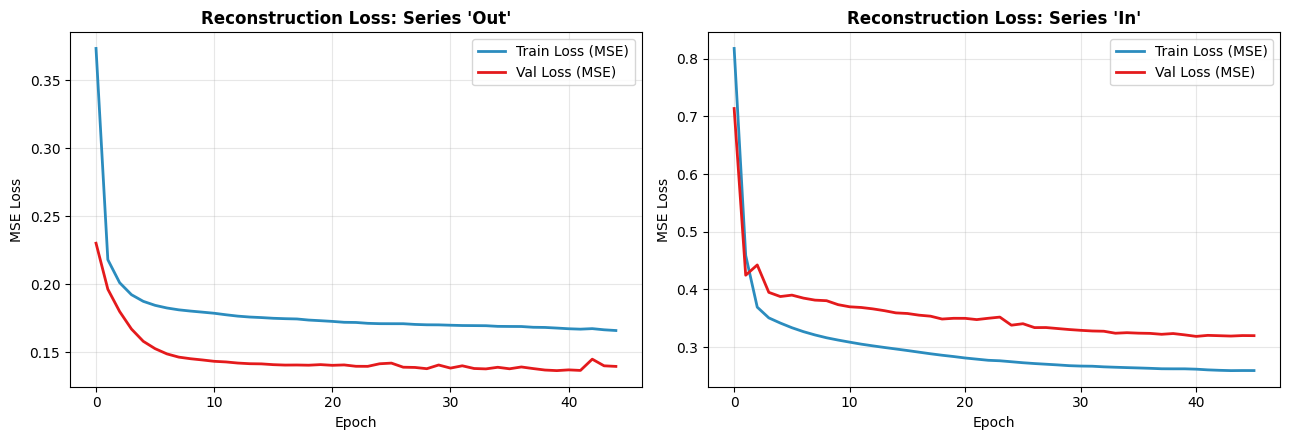

Training Run Summary:
Series Out: {'series': 'Out', 'architecture': 'LSTM(32)-RepeatVector(30)-LSTM(32)-Dense(2)', 'n_train_windows': 11494, 'n_val_windows': 1272, 'batch_size': 256, 'max_epochs': 50, 'epochs_trained': 45, 'final_train_loss': 0.1658749133348465, 'final_val_loss': 0.13944947719573975, 'best_val_loss': 0.13635191321372986, 'training_wall_clock_sec': 30.31, 'gpu_device': 'Tesla T4'}
Series In : {'series': 'In', 'architecture': 'LSTM(32)-RepeatVector(30)-LSTM(32)-Dense(2)', 'n_train_windows': 2978, 'n_val_windows': 326, 'batch_size': 256, 'max_epochs': 50, 'epochs_trained': 46, 'final_train_loss': 0.2591835856437683, 'final_val_loss': 0.31973564624786377, 'best_val_loss': 0.3184654712677002, 'training_wall_clock_sec': 14.53, 'gpu_device': 'Tesla T4'}


In [8]:
# 7. Loss Curves & Training Diagnostics
import matplotlib.pyplot as plt

histories_to_plot = []
if 'history_out' in globals():
    histories_to_plot.append(('Out', history_out))
if 'history_in' in globals():
    histories_to_plot.append(('In', history_in))

n_plots = len(histories_to_plot)
if n_plots > 0:
    fig, axes = plt.subplots(1, n_plots, figsize=(6.5 * n_plots, 4.5))
    if n_plots == 1:
        axes = [axes]
    for ax, (s_name, hist) in zip(axes, histories_to_plot):
        ax.plot(hist.history['loss'], label='Train Loss (MSE)', color='#2b8cbe', linewidth=2)
        ax.plot(hist.history['val_loss'], label='Val Loss (MSE)', color='#e41a1c', linewidth=2)
        ax.set_title(f"Reconstruction Loss: Series '{s_name}'", fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE Loss')
        ax.legend(frameon=True)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No training history found. Please run cell 5 and cell 6 first.')

print('Training Run Summary:')
if 'log_out' in globals():
    print('Series Out:', log_out)
if 'log_in' in globals():
    print('Series In :', log_in)


In [9]:
# 8. Commit & Push Trained Models and Logs Directly to GitHub
import os

print("Configuring git user credentials...")
!git config user.name "Krishna200608"
!git config user.email "krishnasikheriya001@gmail.com"

# Ensure origin remote is authenticated with PAT
!git remote set-url origin https://{GITHUB_TOKEN}@github.com/Krishna200608/coldchain-ews-twin.git

# Stage trained model weights and logs (using -f to override .gitignore for these specific artifacts)
!git add -f models/lstm_out.h5 models/lstm_in.h5 data/processed/lstm_training_log_out.json data/processed/lstm_training_log_in.json

# Check staged changes
!git status

# Commit and push
!git commit -m "feat(colab): add trained LSTM-Autoencoder weights and training logs from Colab T4 GPU"
!git push origin main

print("\nSuccessfully pushed trained models and training logs to GitHub origin/main!")


Configuring git user credentials...
On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   data/processed/lstm_training_log_in.json
	new file:   data/processed/lstm_training_log_out.json
	new file:   models/lstm_in.h5
	new file:   models/lstm_out.h5

[main 9c7680f] feat(colab): add trained LSTM-Autoencoder weights and training logs from Colab T4 GPU
 4 files changed, 28 insertions(+)
 create mode 100644 data/processed/lstm_training_log_in.json
 create mode 100644 data/processed/lstm_training_log_out.json
 create mode 100644 models/lstm_in.h5
 create mode 100644 models/lstm_out.h5
Enumerating objects: 12, done.
Counting objects: 100% (12/12), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (9/9), 295.38 KiB | 17.38 MiB/s, done.
Total 9 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 2

### 9. Verification & Next Steps
Once the push succeeds from Colab, the GitHub repository will contain:
- `models/lstm_out.h5`
- `models/lstm_in.h5`
- `data/processed/lstm_training_log_out.json`
- `data/processed/lstm_training_log_in.json`

On your local machine, run:
```bash
git pull origin main
```
to synchronize the trained models and training logs locally.
Then proceed to Milestone 4b (evaluating reconstruction error on test-side windows and benchmarking early warning lead times against Isolation Forest and the Naive Baseline).
